## Introduction

In the rapidly growing e-commerce industry, understanding customer purchasing behavior is essential for business success. Different customers contribute differently to revenue — some are loyal high-value customers, while others may be inactive or at risk of churn.

This project focuses on analyzing customer transaction data to identify meaningful customer segments. By applying RFM (Recency, Frequency, Monetary) analysis and K-Means clustering, customers are grouped based on their purchasing patterns.

The objective is to help businesses design targeted marketing strategies, improve customer retention, and increase overall revenue through data-driven decision making.

## Problem Statement

E-commerce businesses generate large amounts of transactional data. However, without proper analysis, it becomes difficult to identify valuable customers and optimize marketing strategies.

The problem addressed in this project is:

How can customer transaction data be used to segment customers into meaningful groups for better business decision-making?

## Dataset Description

The dataset used in this project is the Online Retail dataset, which contains transactional records from a UK-based online retail store.

Key features include:

- InvoiceNo: Unique transaction identifier
- StockCode: Product code
- Description: Product name
- Quantity: Number of items purchased
- InvoiceDate: Date and time of transaction
- UnitPrice: Price per item
- CustomerID: Unique customer identifier
- Country: Country of the customer

Each row represents a product purchased in a transaction.

## Data Cleaning

Before analysis, the dataset was cleaned to ensure accuracy:

- Removed rows with missing CustomerID values since customer identification is required for segmentation.
- Excluded cancelled transactions (Invoice numbers starting with 'C').
- Removed records with negative or zero quantities to eliminate returns and invalid transactions.
- Created a new feature, TotalPrice, calculated as Quantity × UnitPrice.

These preprocessing steps ensure that the analysis reflects genuine customer purchasing behavior.

## RFM Analysis

RFM stands for:

- Recency: How recently a customer made a purchase.
- Frequency: How often a customer makes purchases.
- Monetary: How much money a customer spends.

RFM analysis is a widely used technique in marketing analytics to identify high-value customers and understand purchasing behavior.

Customers with low Recency, high Frequency, and high Monetary values are generally considered the most valuable customers.

## Customer Segmentation using K-Means Clustering

Since predefined customer categories are not available, an unsupervised machine learning approach is applied.

K-Means clustering is used to group customers based on similarities in their RFM values. Before applying K-Means, the data is scaled using StandardScaler to ensure that all features contribute equally.

The Elbow Method is used to determine the optimal number of clusters.

## Results and Interpretation

The clustering process resulted in distinct customer segments:

- High-Value Customers: Customers with high frequency and high spending. These customers contribute significantly to revenue.
- At-Risk Customers: Customers who have not purchased recently. These customers may require targeted re-engagement campaigns.
- Low-Value Customers: Customers with low spending and low purchase frequency.

This segmentation enables businesses to implement personalized marketing strategies rather than applying a generic approach to all customers.

## Conclusion

This project demonstrates how machine learning techniques can be applied to real-world e-commerce data to extract actionable insights.

By combining RFM analysis with K-Means clustering, customers were segmented into meaningful groups that can help businesses improve customer retention and revenue strategies.

Customer segmentation is a powerful analytical tool for modern data-driven organizations.

## Future Scope

- Implement advanced clustering techniques such as Hierarchical Clustering or DBSCAN.
- Build a dashboard for real-time customer segmentation.
- Integrate predictive modeling to forecast customer lifetime value.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [7]:
import zipfile
import os

zip_path = "online+retail.zip"   # make sure this matches your file name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("online_retail_data")

print(os.listdir("online_retail_data"))

['Online Retail.xlsx']


In [8]:
import pandas as pd

df = pd.read_excel("online_retail_data/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df = df.dropna(subset=['CustomerID'])

In [11]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [12]:
df = df[df['Quantity'] > 0]

In [13]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [16]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [17]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

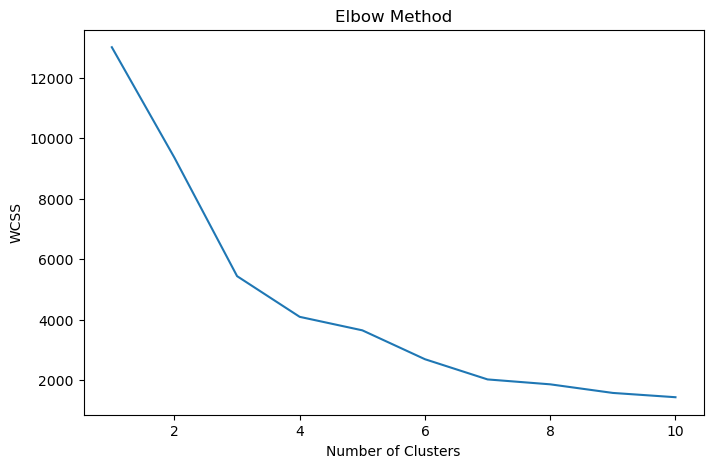

In [18]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [21]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,41.445682,4.671928,1855.367927
1,247.106285,1.582255,631.424206
2,6.038462,66.500000,85904.351538


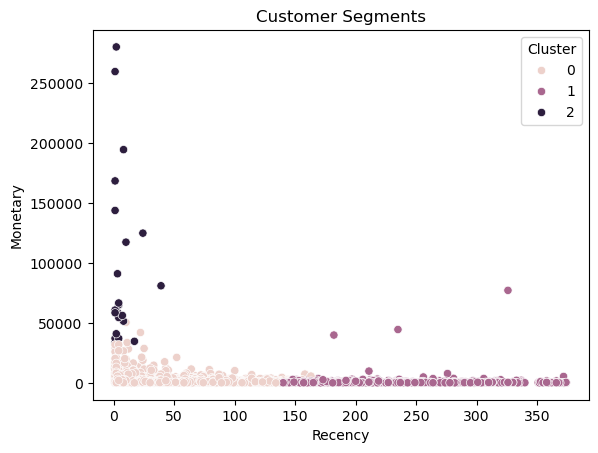

In [22]:
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster')
plt.title("Customer Segments")
plt.show()